In [3]:
!git config --global user.name "sxrthk17"
!git config --global user.email "mulesarthak17@gmail.com"

In [4]:
!git clone https://github.com/sxrthk17/mathematical-foundations-for-ml.git

Cloning into 'mathematical-foundations-for-ml'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (8/8), done.
remote: Total 8 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 5.14 KiB | 5.14 MiB/s, done.
Resolving deltas: 100% (1/1), done.


In [5]:
!ls

mathematical-foundations-for-ml  sample_data


In [6]:
%cd mathematical-foundations-for-ml
#!pwd

/content/mathematical-foundations-for-ml


In [8]:
!ls

LICENSE  README.md


In [9]:
!mkdir -p statistics/descriptive_statistics

In [10]:
!ls
!ls statistics

LICENSE  README.md  statistics
descriptive_statistics


In [11]:
!ls /content

mathematical-foundations-for-ml  sample_data


In [17]:
!find /content -name "*.ipynb"

### MEASURE OF CENTRAL TENDENCY

1.Mean\
2.Mode\
3.Median

In [ ]:
import random

# Generate a list of 10 random integers between 1 and 100
random_numbers = [random.randint(20, 50) for _ in range(10)]
print(random_numbers)

[43, 32, 37, 21, 22, 44, 44, 45, 30, 33]


In [ ]:
import numpy as np

ages = [46, 37, 49, 45, 39, 49, 25, 32, 34, 39]
print(np.mean(ages))
print(np.median(ages))

39.5
39.0


mean vs meadian when it comes to outliers

In [ ]:
ages = [46, 37, 49, 45, 39, 49, 25, 32, 34, 39, 100] #adding 100 as an outlier here

print(np.mean(ages)) # value goes from 39.5 to 45.0
# mean tend to get affected when an outlier shows up and it is not effective for finding out central tendency okay

# but on the other hand median don't get that much affected when it comes to outliers so it is suggested to use median to get the central measure if a data has outlier

print(np.median(ages)) #39. remains 39.


45.0
39.0


using statistics module


In [ ]:
import statistics

print(statistics.mean(ages), statistics.median(ages))

# for most frequent elements we must use mode. numpy don't have mde function but statistics do
print(statistics.mode(ages))

45 39
49


##### finding outliers

<Axes: >

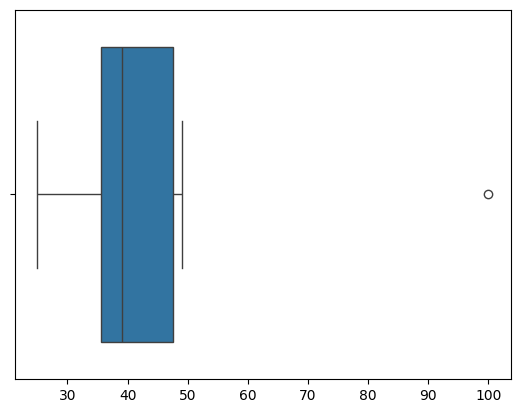

In [ ]:
# we can find outliers using boxplot
import seaborn as sea
sea.boxplot(ages, orient='h')

We will use 5 NUMBER SUMMARY to get \
1.Minimumvalue\
25th percentile\
Median\
75th Percentile\
Max Value

we will also find lower and upper fence that is Q1 and Q3.


In [ ]:
## 5 Number Summary

import numpy as np
q1, q3 = np.percentile(ages, [25,75]) # from dataset ages give 25th and 75th percentile

# to check outlier

IQR = q3 - q1
lower_fence = q1 - 1.5*(IQR)
higher_fence = q3 + 1.5*(IQR)

print(f"[{lower_fence} to {higher_fence}]")

for age in ages:
  if not lower_fence <= age <= higher_fence:
    print(f"{age} is an outlier")


[17.5 to 65.5]
100 is an outlier


### MEASURE OF DISPERSION..

In [ ]:
import statistics, numpy as np
print(statistics.variance(ages)) # uses sample variance formula.. i.e /n+1

print(statistics.pvariance(ages)) ##
print(np.var(ages, axis=0)) #uses population variance formula.. i.e /n

388.4
353.09090909090907
353.09090909090907


In [ ]:
# for standard deviation
import math
math.sqrt(statistics.pvariance(ages))

18.790713373656388

In [ ]:
## Manually calculating Variance for Population and Sample

def variance(data):
  n = len(data)
  # for mean
  mean = sum(data) / n #pop mean
  deviation = [(x - mean)**2 for x in data] # Use 'data' not 'ages'
  varince = sum(deviation) / n # Population variance

  return variance

def sample_variance(data):
   n = len(data)
    # for mean
   mean = sum(data) / n # Mean for sample is calculated the same as population mean
   deviation = [(x - mean)**2 for x in data] # Use 'data' not 'ages'
   varince = sum(deviation) / (n - 1) # Sample variance
   return varince

var = variance(ages)
svar = sample_variance(ages)
print(var , svar)

<function variance at 0x7867cc04cfe0> 388.4


In [ ]:
# variance with your own D.O.F
def variance(data, dof=0):
  n = len(data)
  #mean
  mean = sum(data)/ n
  ##variance
  deviation = [(x - mean) ** 2 for x in data]
  variance = sum(deviation) / (n-dof)
  return variance

print(variance(ages, 2))

431.55555555555554


#### Histogram and PDF's


<Axes: ylabel='Count'>

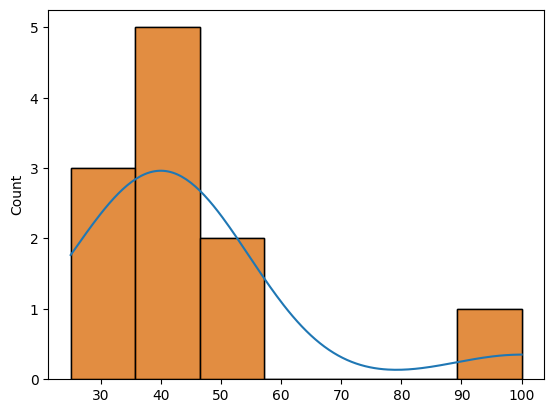

In [ ]:
import seaborn as sea
sea.histplot(ages, kde =True) #histogram apko continuos value ka frequency deta h bhai!!
sea.histplot(ages)


In [ ]:
from urllib.request import urlretrieve
iris_url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
urlretrieve(iris_url, '/content/iris.csv')

('/content/iris.csv', <http.client.HTTPMessage at 0x7867c920f1a0>)

In [ ]:
df = sea.load_dataset("iris")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Count'>

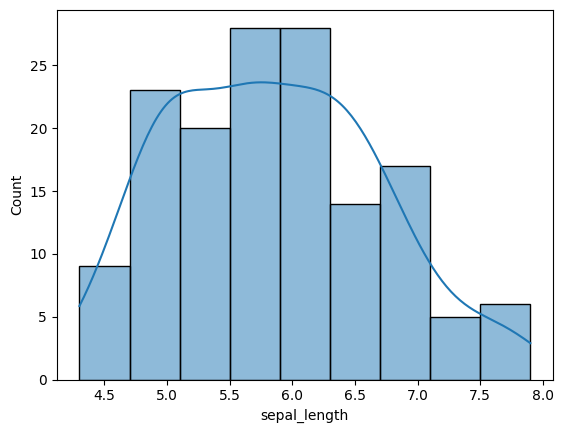

In [ ]:
sea.histplot(df['sepal_length'], kde=True)

<Axes: xlabel='sepal_width', ylabel='Count'>

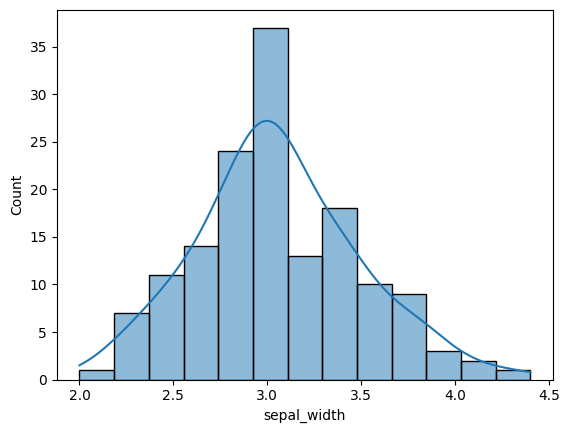

In [ ]:
sea.histplot(df['sepal_width'], kde = True) ## Normal Distribution..

<Axes: xlabel='petal_width', ylabel='Count'>

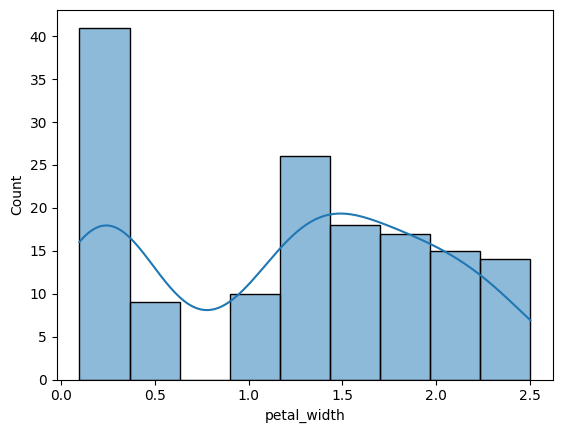

In [ ]:
sea.histplot(df['petal_width'],kde = True)

#### Creating Normal Distribution



<Axes: ylabel='Count'>

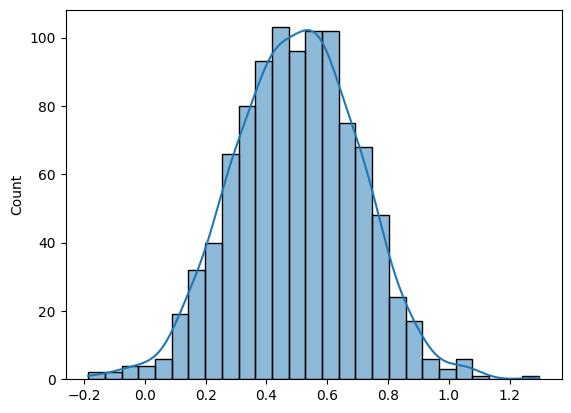

In [ ]:
import numpy as np
## create a normal distibuted data
s = np.random.normal(0.5, 0.2, 1000) # .5 = 2, .2 = std, 1000 = datapoints
sea.histplot(s, kde = True
             )

#### Other DIstirbution

<Axes: ylabel='Count'>

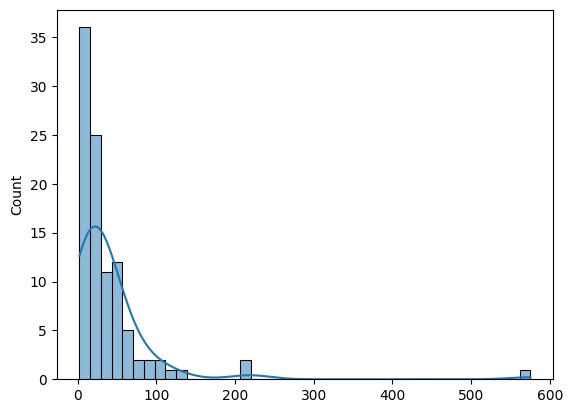

In [ ]:
mu, sigma = 3., 1. ## mean and std
s = np.random.lognormal(mu, sigma, 100)
sea.histplot(s, kde=True)

<Axes: ylabel='Count'>

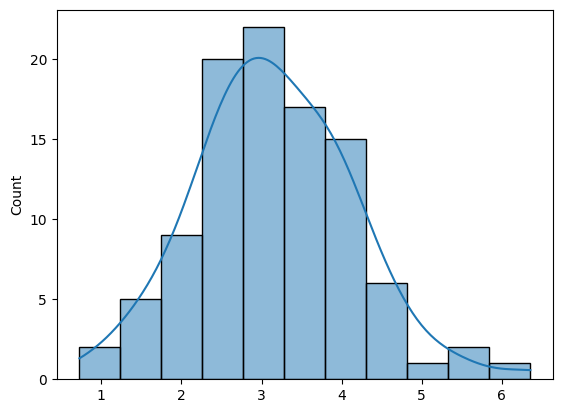

In [ ]:
## agar s pe ab log apply kringe toh normal distribution mil jayega apne ko

sea.histplot(np.log(s), kde=True)

### Check whether distribution is Normal or not




In [ ]:
# Q-Q Plot
import matplotlib.pyplot as plt
import scipy.stats as stat
import pylab, seaborn as sea

def plot_data(sample):
  plt.figure(figsize = (10,6))
  plt.subplot(1,2,1)
  sea.histplot(sample)
  plt.subplot(1,2,2)
  stat.probplot(sample, dist='norm', plot= pylab)
  plt.show()

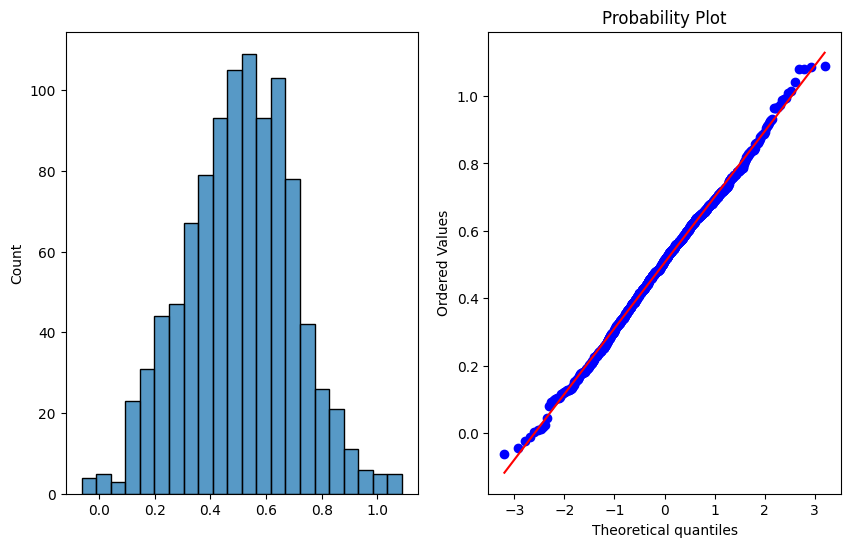

In [ ]:
## create a normal distirbuted data
import numpy as np
s = np.random.normal(0.5, 0.2, 1000)
plot_data(s)

In [ ]:
mu , sigma = 3., 1.
sample = np.random.lognormal(mu, sigma, 100)


In [ ]:
def plot_data_log(sample):
  plt.figure(figsize = (10, 6))
  plt.subplot(1,2,1)
  sea.histplot(sample)
  plt.subplot(1,2,2)
  stat.probplot(np.log(sample), dist = 'norm', plot = pylab) #log for lognorm to norm
  plt.show()

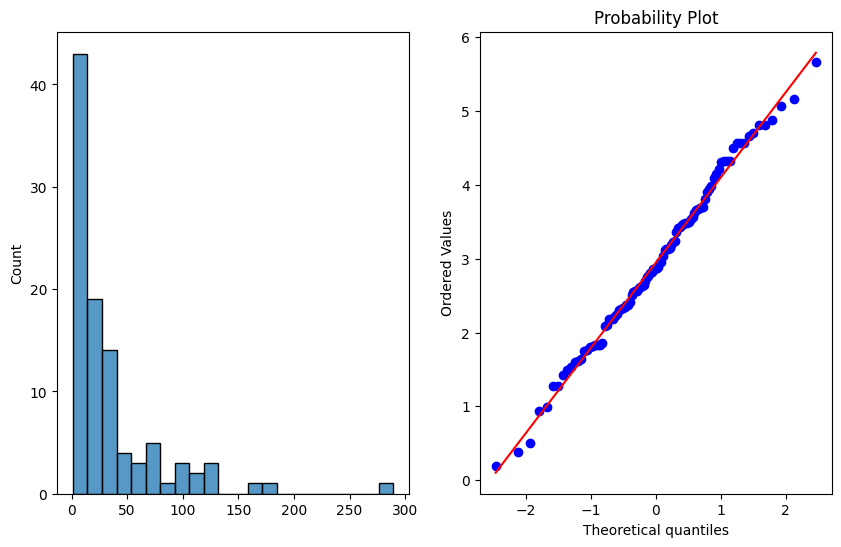

In [ ]:
plot_data_log(sample)